# Setup

In [1]:
import os
from pathlib import Path

import pandas as pd

import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdFingerprintGenerator
from rdkit import DataStructs


PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))

tox21_df = pd.read_csv(DATA_DIR / "tox21.csv")
print(tox21_df.shape)

(7831, 14)


In [2]:
def print_descriptors(mol: rdkit.Chem.rdchem.Mol):
    mol_weight = Descriptors.MolWt(mol)
    log_p = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    molar_refractivity = Descriptors.MolMR(mol)
    rot_bonds = Lipinski.NumRotatableBonds(mol)
    h_donors = Lipinski.NumHDonors(mol)
    h_acceptors = Lipinski.NumHAcceptors(mol)
    fsp3 = Lipinski.FractionCSP3(mol)
    aromatic_rings = Lipinski.NumAromaticRings(mol)
    heavy_atoms = Lipinski.HeavyAtomCount(mol)

    display(
        pd.DataFrame(
            {
                "Molecular Weight": f"{mol_weight:.2f} g/mol",
                "Calculated LogP (Wildman)": f"{log_p:.2f}",
                "Rotatable Bonds": rot_bonds,
                "H-Bond Donors": h_donors,
                "H-Bond Acceptors": h_acceptors,
                "TPSA": f"{tpsa:.2f} Å²",
                "Fraction CSP3 (Fsp3)": f"{fsp3:.2f}",
                "Molar Refractivity": f"{molar_refractivity:.2f}",
                "Aromatic Rings": aromatic_rings,
                "Heavy Atom Count": heavy_atoms,
            },
            index=[0],
        )
    )

# Ethoxzolamide

'CCOc1ccc2nc(S(N)(=O)=O)sc2c1'

,Molecular Weight,Calculated LogP (Wildman),Rotatable Bonds,H-Bond Donors,H-Bond Acceptors,TPSA,Fraction CSP3 (Fsp3),Molar Refractivity,Aromatic Rings,Heavy Atom Count
0,258.32 g/mol,1.34,3,1,5,82.28 Å²,0.22,62.16,2,16


{69: ((2, 2),),
 80: ((1, 0),),
 159: ((8, 2),),
 162: ((13, 1),),
 237: ((1, 2),),
 294: ((0, 1),),
 322: ((3, 1),),
 350: ((9, 0),),
 371: ((9, 2),),
 378: ((7, 0),),
 485: ((8, 1),),
 493: ((15, 2),),
 557: ((6, 2),),
 650: ((11, 0), (12, 0)),
 675: ((13, 0),),
 695: ((2, 0),),
 705: ((7, 2),),
 718: ((4, 2),),
 833: ((9, 1),),
 875: ((15, 1),),
 885: ((14, 1),),
 961: ((5, 2),),
 1057: ((0, 0),),
 1080: ((13, 2),),
 1097: ((6, 1),),
 1171: ((10, 0),),
 1238: ((1, 1),),
 1380: ((3, 0), (6, 0), (8, 0), (14, 0)),
 1452: ((2, 1),),
 1476: ((11, 1), (12, 1)),
 1501: ((3, 2),),
 1607: ((10, 1),),
 1669: ((14, 2),),
 1750: ((4, 1), (5, 1)),
 1855: ((7, 1),),
 1873: ((4, 0), (5, 0), (15, 0))}

'CCN1C(=O)NC(c2ccccc2)C1=O'

,Molecular Weight,Calculated LogP (Wildman),Rotatable Bonds,H-Bond Donors,H-Bond Acceptors,TPSA,Fraction CSP3 (Fsp3),Molar Refractivity,Aromatic Rings,Heavy Atom Count
0,204.23 g/mol,1.30,2,1,2,49.41 Å²,0.27,55.10,1,15


Ethoxzolamide Active Bits: 36
Acetazolamide Active Bits: 28
Tanimoto Similarity Index:  0.1228


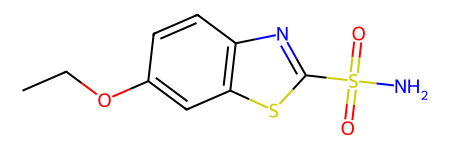

In [3]:
def process_ethoxzolamide():
    ethoxzolamide_smiles = tox21_df.loc[tox21_df["mol_id"] == "TOX3021"]["smiles"]
    display(ethoxzolamide_smiles.iloc[0])

    ethoxzolamide_mol = Chem.MolFromSmiles(ethoxzolamide_smiles.iloc[0])
    print_descriptors(ethoxzolamide_mol)

    # Generate Morgan Fingerprints (ECFP4 equivalent)
    # Radius=2 corresponds to a maximum diameter of 4 bonds (ECFP4)
    # fpSize=2048 is the standard bit-vector length to minimize bit collisions
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateBitInfoMap()

    # Generate Binary Bit Vector
    ethoxzolamide_fp = generator.GetFingerprint(ethoxzolamide_mol, additionalOutput=ao)
    display(ao.GetBitInfoMap())

    ethoxzolamide_mol = Chem.MolFromSmiles(ethoxzolamide_smiles.iloc[0])

    smiles = tox21_df.loc[tox21_df["mol_id"] != "TOX3021"]["smiles"]
    display(smiles.iloc[0])
    mol = Chem.MolFromSmiles(smiles.iloc[0])
    print_descriptors(mol)
    finger_print = generator.GetFingerprint(mol)

    # Calculate Tanimoto Similarity (ranges from 0.0 to 1.0)
    tanimoto_similarity = DataStructs.TanimotoSimilarity(ethoxzolamide_fp, finger_print)

    print(f"Ethoxzolamide Active Bits: {ethoxzolamide_fp.GetNumOnBits()}")
    print(f"Acetazolamide Active Bits: {finger_print.GetNumOnBits()}")
    print(f"Tanimoto Similarity Index:  {tanimoto_similarity:.4f}")

    return ethoxzolamide_mol


process_ethoxzolamide()